In [1]:
import numpy as np
import matplotlib.pyplot as plt
import KZ as kz

In [9]:
kz.DOF, kz.dx      = 1024, 0.5
kz.eta, kz.theta   = 1.0, 1e-8
kz.EPS_I, kz.EPS_F = -1.5, 1.0
kz.TAU             = 128.0

DT       = 0.05
SEED     = 1337
T_CENTER = [30, 50]
WIN      = 5

n_steps = int(round((kz.EPS_F - kz.EPS_I)*kz.TAU/DT))
t_hist, dt = kz.make_time_grid(n_steps)
stride = max(1, int(round(1.0/dt)))

phi, pi = kz.run(t_hist, dt, seed=SEED, stride=stride)

ts = t_hist[::stride][:len(phi)]
x  = kz.grid()
ix = lambda tt: int(np.argmin(abs(ts - tt)))

X = {tc: np.stack([phi[ix(tc + k)] for k in range(-WIN, WIN+1)]) for tc in T_CENTER}
Y = phi[-1]
true_pos = kz.defect_positions(Y)
n_true   = kz.count_defects(Y)

print(n_true, 'defects')
for tc in T_CENTER:
    print(tc, X[tc].shape, np.abs(X[tc]).max())

6 defects
30 (11, 1024) 0.003472775163498786
50 (11, 1024) 0.05986311303309539


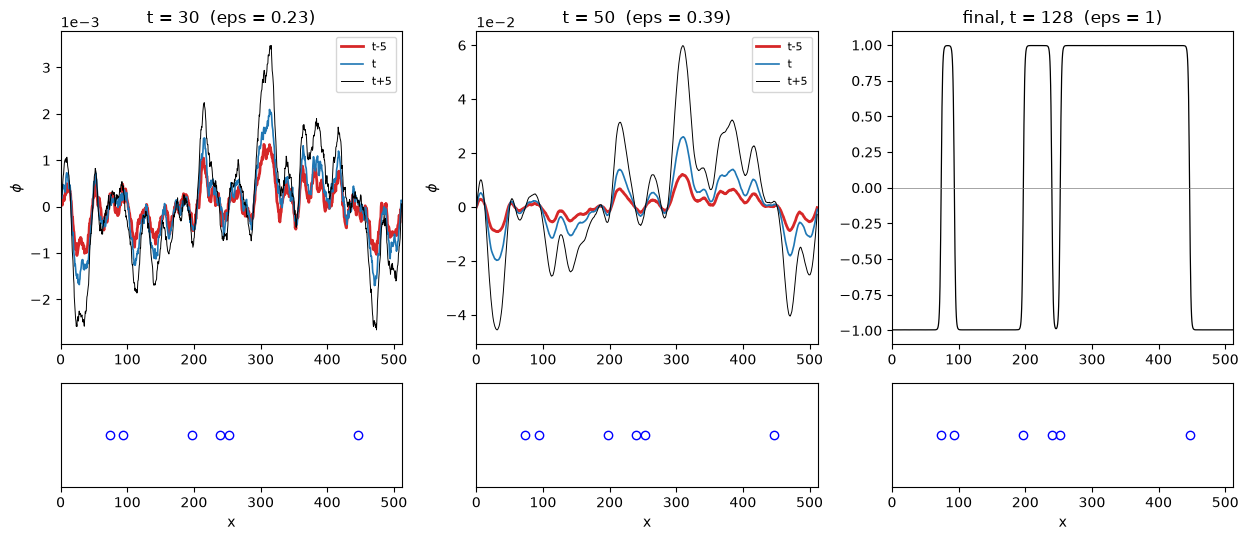

In [10]:
fig, axes = plt.subplots(2, len(T_CENTER)+1, figsize=(4.2*(len(T_CENTER)+1), 5.5),
                         gridspec_kw={'height_ratios': [3, 1]})

for col, tc in enumerate(T_CENTER):
    W = X[tc]
    ax = axes[0, col]
    ax.plot(x, W[0],   color='tab:red',  lw=2.0, label='t-5')
    ax.plot(x, W[WIN], color='tab:blue', lw=1.2, label='t')
    ax.plot(x, W[-1],  color='k',        lw=0.7, label='t+5')
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
    ax.set_title(f't = {tc}  (eps = {tc/kz.TAU:.2f})')
    ax.set_ylabel(r'$\phi$'); ax.legend(fontsize=8)

    ax = axes[1, col]
    ax.plot(true_pos, np.zeros(n_true), 'o', mfc='none', mec='b', ms=6)
    ax.set_yticks([]); ax.set_xlabel('x')

ax = axes[0, -1]
ax.plot(x, Y, 'k-', lw=0.9)
ax.axhline(0, color='grey', lw=0.5)
ax.set_title(f'final, t = {ts[-1]:.0f}  (eps = 1)')

ax = axes[1, -1]
ax.plot(true_pos, np.zeros(n_true), 'o', mfc='none', mec='b', ms=6)
ax.set_yticks([]); ax.set_xlabel('x')

for a in axes.ravel():
    a.set_xlim(0, kz.L())
plt.tight_layout()

In [11]:
for tc in T_CENTER:
    for k in [0, WIN, -1]:
        p = kz.defect_positions(X[tc][k])
        print(tc, k, len(p), np.round(p[:8], 1))
print('final', n_true, np.round(true_pos[:8], 1))

30 0 52 [16.5 47.4 47.7 48.  59.5 72.1 81.1 88.4]
30 5 46 [ 16.1  48.2  56.7  72.6  85.9  86.3 101.2 127.8]
30 -1 28 [15.3 48.3 56.  69.4 69.7 70.6 73.3 73.9]
50 0 14 [1.000e-01 1.400e+01 4.820e+01 5.720e+01 7.390e+01 9.670e+01 1.821e+02
 1.902e+02]
50 5 14 [1.000e-01 1.330e+01 4.910e+01 5.830e+01 7.380e+01 9.680e+01 1.827e+02
 1.898e+02]
50 -1 14 [  0.4  12.7  50.1  58.   73.7  96.1 183.8 188.6]
final 6 [ 73.7  93.5 197.  239.8 252.4 446.5]


In [4]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("../data/2D/chunk_000.npz")

for key in d.files:
    print(key, d[key].shape)

print("snap_times:", d["snap_times"])

snaps (2, 33, 128, 128)
snap_times (33,)
phi_final (2, 128, 128)
wall_len (2,)
seed ()
dt ()
tau ()
N ()
snap_times: [15 16 17 18 19 20 21 22 23 24 25 45 46 47 48 49 50 51 52 53 54 55 65 66
 67 68 69 70 71 72 73 74 75]


In [5]:
snaps = d["snaps"]

for i, t in enumerate(d["snap_times"]):
    print(t, np.abs(snaps[0, i]).max())

15 0.0003418141
16 0.0003442037
17 0.0004007643
18 0.00038861384
19 0.00036857466
20 0.000383278
21 0.00044772302
22 0.00040011792
23 0.00040033995
24 0.00042876127
25 0.00045410206
45 0.0019170719
46 0.002179048
47 0.0024513267
48 0.002738815
49 0.0031643678
50 0.0036650586
51 0.004212103
52 0.004900661
53 0.005688578
54 0.00673207
55 0.007950455
65 0.048883338
66 0.05965366
67 0.07308867
68 0.08959487
69 0.11018478
70 0.13553107
71 0.16708599
72 0.20578493
73 0.25307834
74 0.309966
75 0.37660107


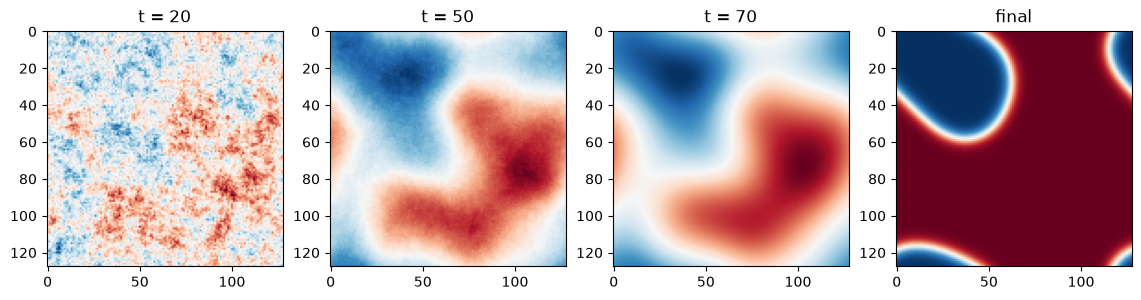

wall lengths: [145. 143.]


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, i in zip(axes[:3], [5, 16, 27]):     # centers of the 3 windows
    ax.imshow(snaps[0, i], cmap="RdBu")
    ax.set_title(f"t = {d['snap_times'][i]}")

axes[3].imshow(d["phi_final"][0], cmap="RdBu")
axes[3].set_title("final")
plt.show()

print("wall lengths:", d["wall_len"])